<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 146.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 105.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 73.1 MB/s eta 0:00:00


**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()


--2026-02-15 21:11:31--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  35.5MB/s    in 4.5s    

2026-02-15 21:11:36 (34.1 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


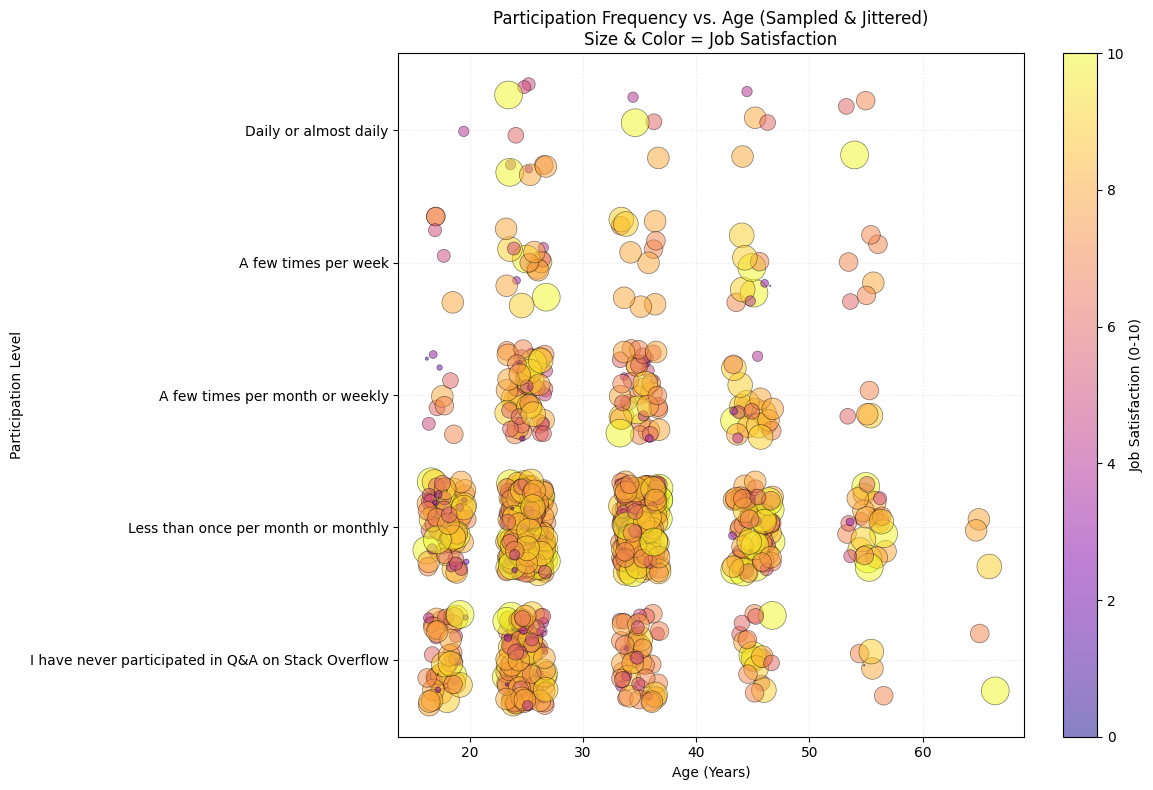

In [9]:
##Write your code here
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

conn = sqlite3.connect('survey-data.sqlite')

query = "SELECT Age, SOPartFreq, JobSat FROM main WHERE Age IS NOT NULL AND SOPartFreq IS NOT NULL AND JobSat IS NOT NULL"
df = pd.read_sql_query(query, conn)

freq_mapping = {
    'I have never participated in Q&A on Stack Overflow': 0,
    'Less than once per month or monthly': 1,
    'A few times per month or weekly': 2,
    'A few times per week': 3,
    'Daily or almost daily': 4
}
df['Freq_Num'] = df['SOPartFreq'].map(freq_mapping)
df['Age_Num'] = df['Age'].str.extract('(\d+)').astype(float)

if len(df) > 1000:
    df_plot = df.sample(n=1000, random_state=42)
else:
    df_plot = df

plt.figure(figsize=(12, 8))

x_jitter = df_plot['Age_Num'] + np.random.uniform(-1.8, 1.8, size=len(df_plot))
y_jitter = df_plot['Freq_Num'] + np.random.uniform(-0.35, 0.35, size=len(df_plot))

bubble_sizes = (df_plot['JobSat'] + 1) ** 2.5 

scatter = plt.scatter(x_jitter, y_jitter, 
                      s=bubble_sizes, 
                      c=df_plot['JobSat'], 
                      cmap='plasma',      # 'plasma' provides high contrast for satisfaction
                      alpha=0.5, 
                      edgecolors='black', 
                      linewidth=0.5)

plt.yticks(ticks=list(freq_mapping.values()), labels=list(freq_mapping.keys()))
plt.title('Participation Frequency vs. Age (Sampled & Jittered)\nSize & Color = Job Satisfaction')
plt.xlabel('Age (Years)')
plt.ylabel('Participation Level')

cbar = plt.colorbar(scatter)
cbar.set_label('Job Satisfaction (0-10)')

plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


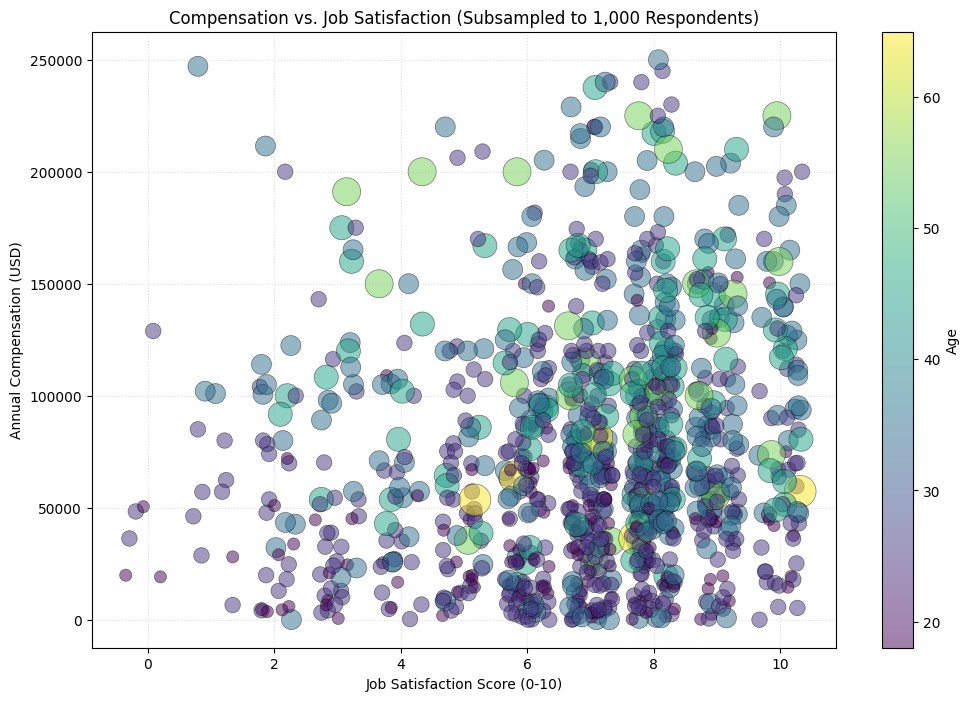

In [7]:
##Write your code here
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Connect and Query
conn = sqlite3.connect('survey-data.sqlite')
query = "SELECT ConvertedCompYearly, JobSat, Age FROM main WHERE ConvertedCompYearly IS NOT NULL AND JobSat IS NOT NULL AND Age IS NOT NULL"
df = pd.read_sql_query(query, conn)

# 2. Pre-process
df['Age_Numeric'] = df['Age'].str.extract('(\d+)').astype(float)
df_filtered = df[df['ConvertedCompYearly'] <= 250000].copy()

# 3. THE FIX: Subsample the data
# If we have 10,000 rows, let's just look at 1,000. 
# This breaks up the "blobs" so you can see individual bubbles.
if len(df_filtered) > 1000:
    df_plot = df_filtered.sample(n=1000, random_state=42)
else:
    df_plot = df_filtered

# 4. Plotting
plt.figure(figsize=(12, 8))

# Increase jitter slightly to further separate the bubbles
x_jitter = df_plot['JobSat'] + np.random.uniform(-0.35, 0.35, size=len(df_plot))
y = df_plot['ConvertedCompYearly']
sizes = (df_plot['Age_Numeric'] ** 1.5) # Using an exponent makes size differences more obvious

scatter = plt.scatter(x_jitter, y, 
                      s=sizes, 
                      alpha=0.5,           # Lower alpha makes overlaps look like "depth"
                      c=df_plot['Age_Numeric'], 
                      cmap='viridis', 
                      edgecolors='black',  # Black edges help distinguish one bubble from another
                      linewidth=0.5)

plt.title('Compensation vs. Job Satisfaction (Subsampled to 1,000 Respondents)')
plt.xlabel('Job Satisfaction Score (0-10)')
plt.ylabel('Annual Compensation (USD)')

# Customizing the Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Age')

plt.grid(True, linestyle=':', alpha=0.4)
plt.show()

conn.close()


### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



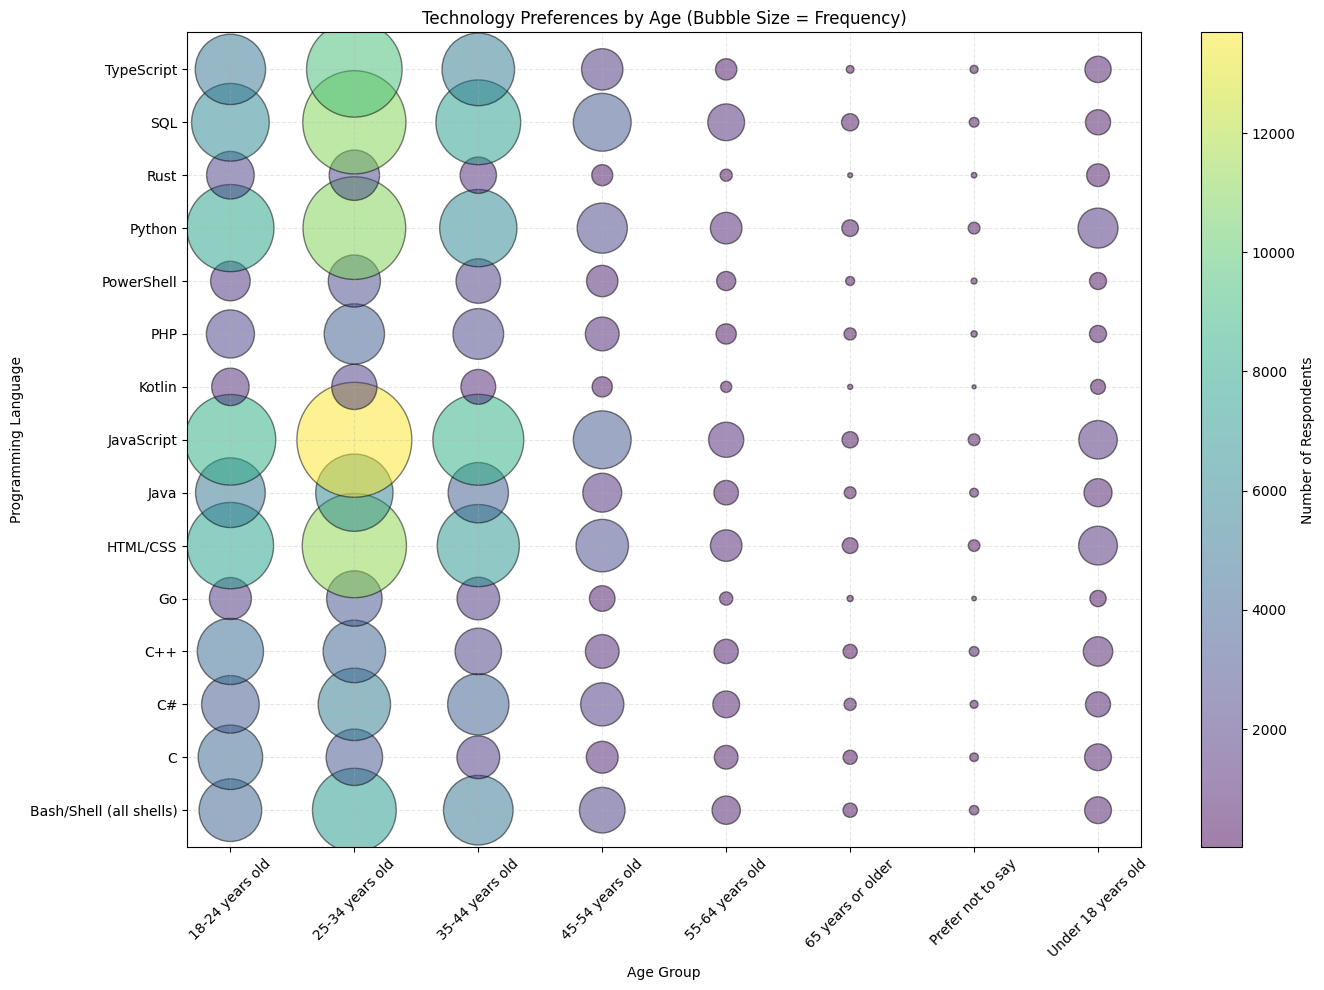

In [11]:
##Write your code here

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('survey-data.sqlite')
query = "SELECT LanguageHaveWorkedWith, Age FROM main WHERE LanguageHaveWorkedWith IS NOT NULL AND Age IS NOT NULL"
df = pd.read_sql_query(query, conn)

df_exploded = df.assign(Language=df['LanguageHaveWorkedWith'].str.split(';')).explode('Language')

bubble_data = df_exploded.groupby(['Age', 'Language']).size().reset_index(name='Count')

top_langs = df_exploded['Language'].value_counts().head(15).index
bubble_data = bubble_data[bubble_data['Language'].isin(top_langs)]

plt.figure(figsize=(14, 10))

scatter = plt.scatter(bubble_data['Age'], 
                      bubble_data['Language'], 
                      s=bubble_data['Count'] * 0.5, 
                      alpha=0.5, 
                      c=bubble_data['Count'], 
                      cmap='viridis', 
                      edgecolors='black')

plt.title('Technology Preferences by Age (Bubble Size = Frequency)')
plt.xlabel('Age Group')
plt.ylabel('Programming Language')
plt.xticks(rotation=45)

plt.colorbar(scatter, label='Number of Respondents')

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


In [ ]:
##Write your code here

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


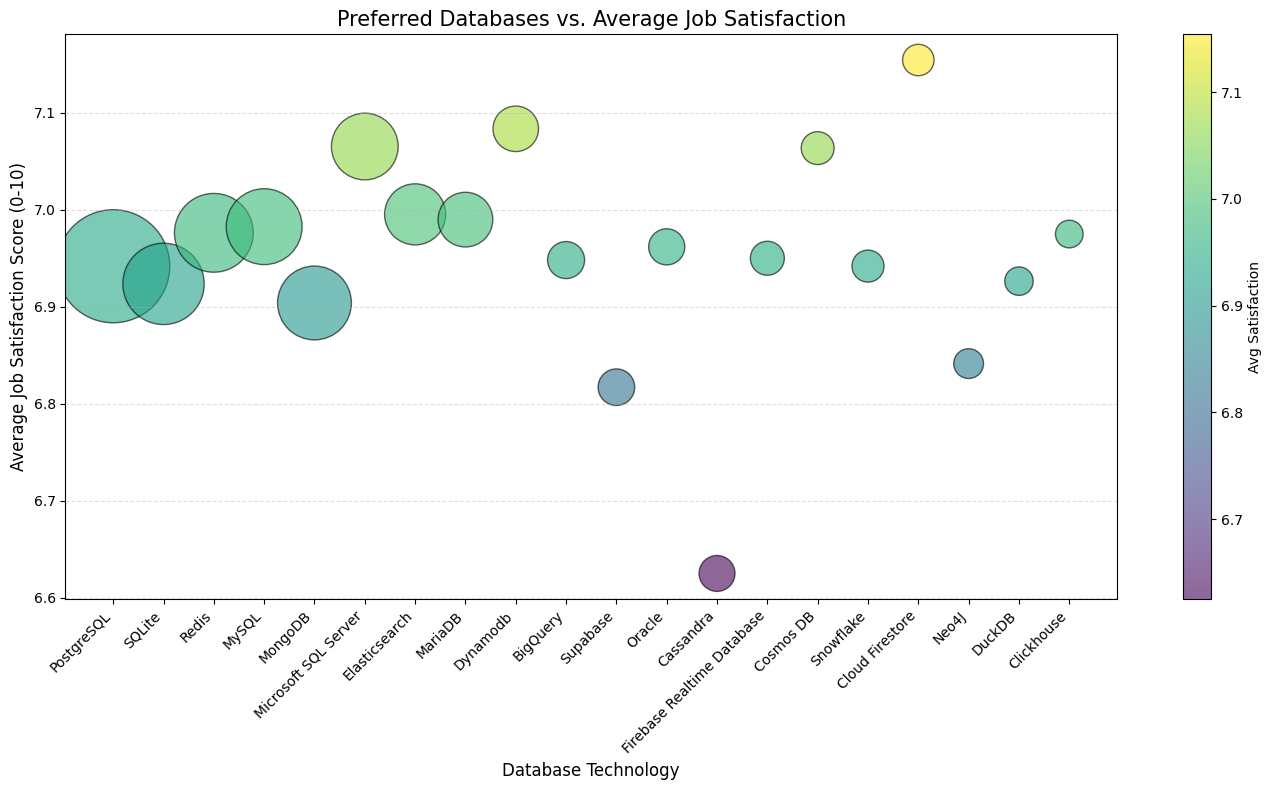

In [13]:
##Write your code here

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('survey-data.sqlite')

query = "SELECT DatabaseWantToWorkWith, JobSat FROM main WHERE DatabaseWantToWorkWith IS NOT NULL AND JobSat IS NOT NULL"
df = pd.read_sql_query(query, conn)

df_exploded = df.assign(Database=df['DatabaseWantToWorkWith'].str.split(';')).explode('Database')

db_stats = df_exploded.groupby('Database').agg(
    AvgJobSat=('JobSat', 'mean'),
    Count=('JobSat', 'count')
).reset_index()

db_stats = db_stats.sort_values(by='Count', ascending=False).head(20)

plt.figure(figsize=(14, 8))

x = db_stats['Database']
y = db_stats['AvgJobSat']

size = db_stats['Count'] * 0.5 

scatter = plt.scatter(x, y, s=size, alpha=0.6, c=y, cmap='viridis', edgecolors='black')

plt.title('Preferred Databases vs. Average Job Satisfaction', fontsize=15)
plt.xlabel('Database Technology', fontsize=12)
plt.ylabel('Average Job Satisfaction Score (0-10)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.colorbar(scatter, label='Avg Satisfaction')

plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


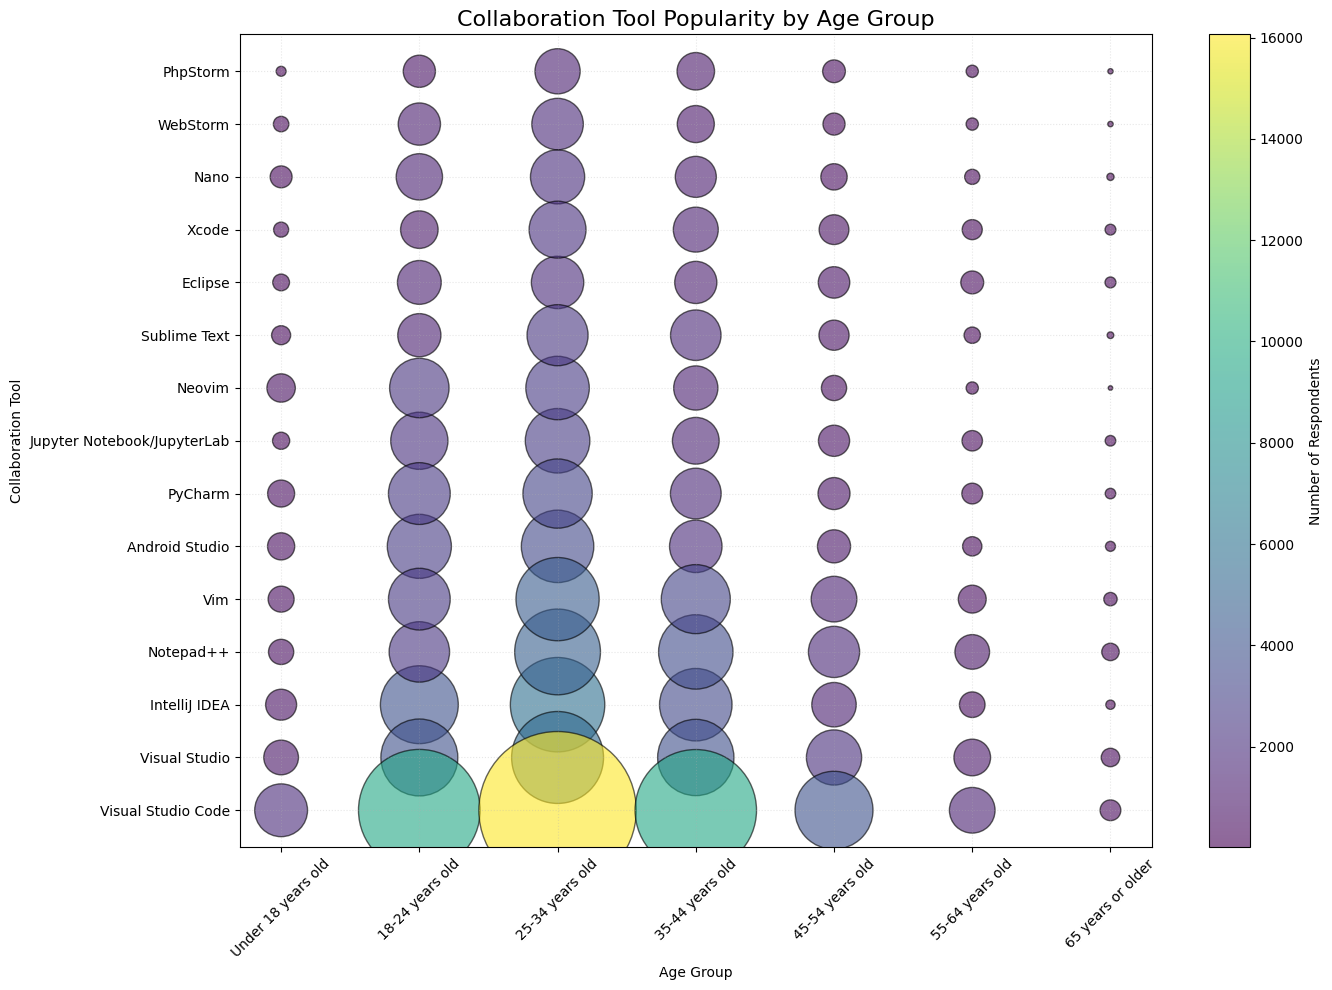

In [18]:
##Write your code here

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Connect and Query
conn = sqlite3.connect('survey-data.sqlite')
query = "SELECT Age, NEWCollabToolsHaveWorkedWith FROM main WHERE Age IS NOT NULL AND NEWCollabToolsHaveWorkedWith IS NOT NULL"
df = pd.read_sql_query(query, conn)

# 2. Unbundle and Filter
df_exploded = df.assign(Tool=df['NEWCollabToolsHaveWorkedWith'].str.split(';')).explode('Tool')
top_tools = df_exploded['Tool'].value_counts().head(15).index.tolist()
df_filtered = df_exploded[df_exploded['Tool'].isin(top_tools)].copy()

# 3. Aggregate
bubble_data = df_filtered.groupby(['Age', 'Tool']).size().reset_index(name='Count')

# 4. MANUALLY MAP TO NUMBERS (The secret sauce to stop the TypeError)
age_order = ['Under 18 years old', '18-24 years old', '25-34 years old', 
             '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older']

# Create mapping dictionaries
age_map = {name: i for i, name in enumerate(age_order)}
tool_map = {name: i for i, name in enumerate(top_tools)}

# Map the data to numbers
bubble_data['x_idx'] = bubble_data['Age'].map(age_map)
bubble_data['y_idx'] = bubble_data['Tool'].map(tool_map)

# Drop any rows that didn't map (handles any sneaky NaNs)
bubble_data = bubble_data.dropna(subset=['x_idx', 'y_idx'])

# 5. Plotting using the numeric indices
plt.figure(figsize=(14, 10))

scatter = plt.scatter(
    bubble_data['x_idx'], 
    bubble_data['y_idx'], 
    s=bubble_data['Count'] * 0.8, 
    alpha=0.6, 
    c=bubble_data['Count'], 
    cmap='viridis', 
    edgecolors='black'
)

# 6. Formatting: RE-LABEL the axes with the original strings
plt.xticks(ticks=range(len(age_order)), labels=age_order, rotation=45)
plt.yticks(ticks=range(len(top_tools)), labels=top_tools)

plt.title('Collaboration Tool Popularity by Age Group', fontsize=16)
plt.xlabel('Age Group')
plt.ylabel('Collaboration Tool')
plt.colorbar(scatter, label='Number of Respondents')
plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()

plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



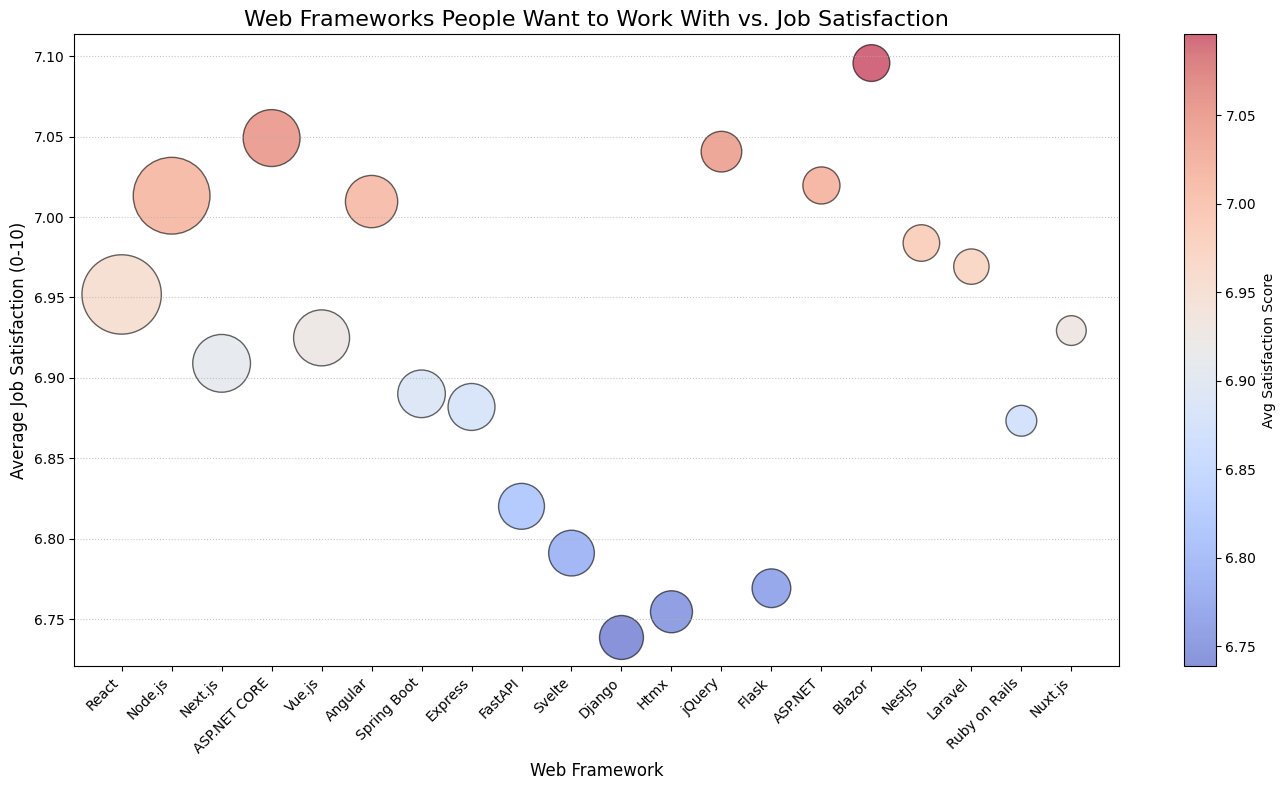

In [20]:
##Write your code here

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('survey-data.sqlite')

query = "SELECT WebframeWantToWorkWith, JobSat FROM main WHERE WebframeWantToWorkWith IS NOT NULL AND JobSat IS NOT NULL"
df = pd.read_sql_query(query, conn)

df_exploded = df.assign(Framework=df['WebframeWantToWorkWith'].str.split(';')).explode('Framework')

framework_stats = df_exploded.groupby('Framework').agg(
    AvgJobSat=('JobSat', 'mean'),
    RespondentCount=('JobSat', 'count')
).reset_index()

framework_stats = framework_stats.sort_values(by='RespondentCount', ascending=False).head(20)

plt.figure(figsize=(14, 8))

x_range = range(len(framework_stats))
y = framework_stats['AvgJobSat']

sizes = framework_stats['RespondentCount'] * 0.4 

scatter = plt.scatter(x_range, y, s=sizes, alpha=0.6, c=y, cmap='coolwarm', edgecolors='black')

plt.title('Web Frameworks People Want to Work With vs. Job Satisfaction', fontsize=16)
plt.ylabel('Average Job Satisfaction (0-10)', fontsize=12)
plt.xlabel('Web Framework', fontsize=12)

plt.xticks(ticks=x_range, labels=framework_stats['Framework'], rotation=45, ha='right')

plt.colorbar(scatter, label='Avg Satisfaction Score')
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



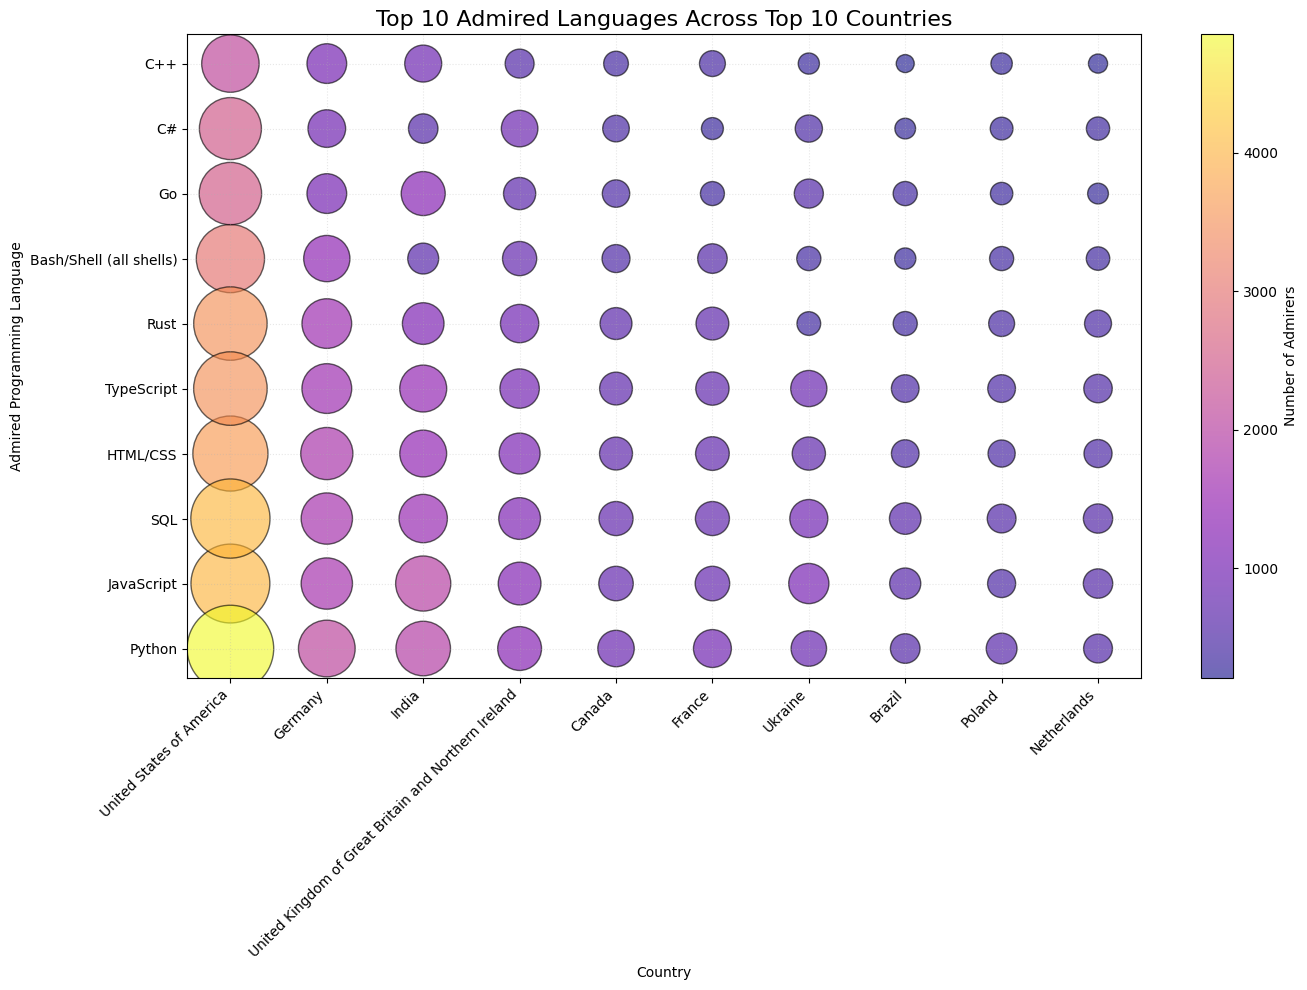

In [22]:
##Write your code here

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('survey-data.sqlite')

query = """
SELECT Country, LanguageWantToWorkWith 
FROM main 
WHERE Country IS NOT NULL AND LanguageWantToWorkWith IS NOT NULL
"""
df = pd.read_sql_query(query, conn)

df_exploded = df.assign(Language=df['LanguageWantToWorkWith'].str.split(';')).explode('Language')

top_countries = df_exploded['Country'].value_counts().head(10).index
top_langs = df_exploded['Language'].value_counts().head(10).index

df_filtered = df_exploded[
    (df_exploded['Country'].isin(top_countries)) & 
    (df_exploded['Language'].isin(top_langs))
]

bubble_data = df_filtered.groupby(['Country', 'Language']).size().reset_index(name='Count')

country_list = top_countries.tolist()
lang_list = top_langs.tolist()

bubble_data['c_idx'] = bubble_data['Country'].map({name: i for i, name in enumerate(country_list)})
bubble_data['l_idx'] = bubble_data['Language'].map({name: i for i, name in enumerate(lang_list)})

plt.figure(figsize=(14, 10))

scatter = plt.scatter(
    bubble_data['c_idx'], 
    bubble_data['l_idx'], 
    s=bubble_data['Count'] * 0.8, 
    alpha=0.6, 
    c=bubble_data['Count'], 
    cmap='plasma', 
    edgecolors='black'
)

plt.xticks(ticks=range(len(country_list)), labels=country_list, rotation=45, ha='right')
plt.yticks(ticks=range(len(lang_list)), labels=lang_list)

plt.title('Top 10 Admired Languages Across Top 10 Countries', fontsize=16)
plt.xlabel('Country')
plt.ylabel('Admired Programming Language')
plt.colorbar(scatter, label='Number of Admirers')

plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

conn.close()

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
